In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv('smart_manufacturing_data.csv',parse_dates=['timestamp'])
print("Shape:",df.shape)
df.head()

Shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[ns]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  object        
 11  downtime_risk             100000 non-null  float64       
 12  mai

In [7]:
df.describe(include='all').T 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,100000,NaN,NaN,NaN,2025-02-04 17:19:29.999999744,2025-01-01 00:00:00,2025-01-18 08:39:45,2025-02-04 17:19:30,2025-02-22 01:59:15,2025-03-11 10:39:00,NaN
machine_id,100000.0,NaN,NaN,NaN,25.49933,1.0,13.0,25.0,38.0,50.0,14.389439
temperature,100000.0,NaN,NaN,NaN,75.015625,35.55,68.2675,75.06,81.75,121.94,10.031884
vibration,100000.0,NaN,NaN,NaN,50.01227,-17.09,39.97,49.96,60.1,113.8,14.985444
humidity,100000.0,NaN,NaN,NaN,54.995401,30.0,42.52,54.98,67.5,80.0,14.43796
pressure,100000.0,NaN,NaN,NaN,3.000405,1.0,2.0,3.01,4.0,5.0,1.152399
energy_consumption,100000.0,NaN,NaN,NaN,2.747064,0.5,1.63,2.74,3.87,5.0,1.297865
machine_status,100000.0,NaN,NaN,NaN,1.00205,0.0,1.0,1.0,1.0,2.0,0.446193
anomaly_flag,100000.0,NaN,NaN,NaN,0.08916,0.0,0.0,0.0,0.0,1.0,0.284976
predicted_remaining_life,100000.0,NaN,NaN,NaN,234.26916,1.0,97.0,230.0,365.0,499.0,150.063062


In [8]:
status_map = {0: 'Idle', 1: 'Running', 2: 'Failure'}
df['machine_status_label'] = df['machine_status'].map(status_map)
df['machine_status_label'].value_counts()

machine_status_label
Running    80091
Failure    10057
Idle        9852
Name: count, dtype: int64

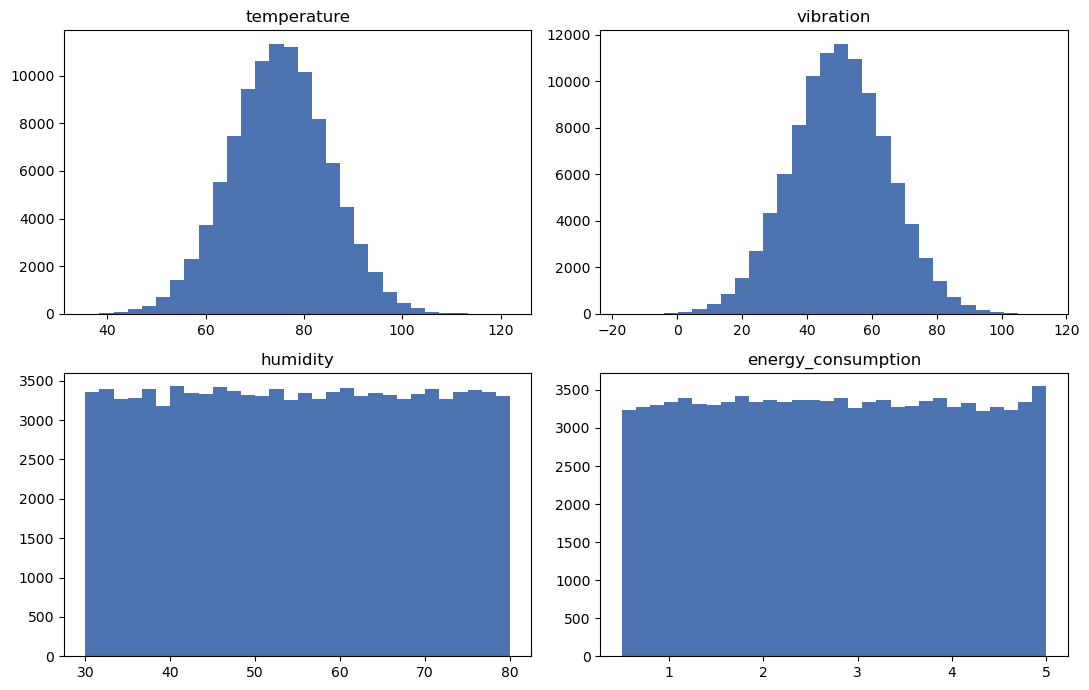

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), ['temperature', 'vibration', 'humidity', 'energy_consumption']):
    ax.hist(df[col].dropna(), bins=30, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=110)
plt.show()

In [10]:
df['maintenance_required'].value_counts(normalize=True).rename('proportion')

maintenance_required
0    0.80303
1    0.19697
Name: proportion, dtype: float64

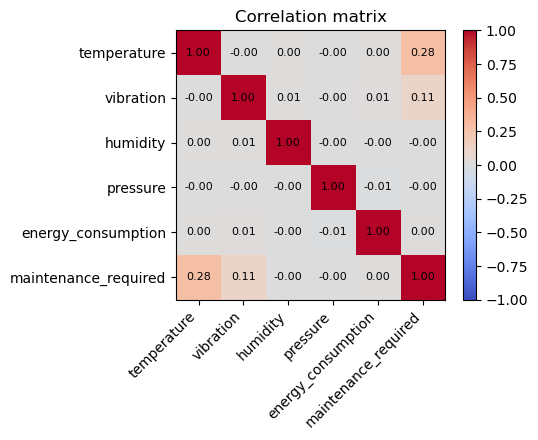

,temperature,vibration,humidity,pressure,energy_consumption,maintenance_required
temperature,1.000000,-0.003251,0.002555,-0.001116,0.003259,0.283021
vibration,-0.003251,1.000000,0.006051,-0.000278,0.007897,0.113072
humidity,0.002555,0.006051,1.000000,-0.000208,-0.002542,-0.003815
pressure,-0.001116,-0.000278,-0.000208,1.000000,-0.008071,-0.001945
energy_consumption,0.003259,0.007897,-0.002542,-0.008071,1.000000,0.001384
maintenance_required,0.283021,0.113072,-0.003815,-0.001945,0.001384,1.000000


In [11]:
corr_cols = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'maintenance_required']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, fraction=0.046)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=110)
plt.show()
corr

In [12]:
print("Missing values per column:")
print(df.isna().sum())
print("\nPercent missing:")
print((df.isna().mean() * 100).round(2))

Missing values per column:
timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
machine_status_label        0
dtype: int64

Percent missing:
timestamp                   0.0
machine_id                  0.0
temperature                 0.0
vibration                   0.0
humidity                    0.0
pressure                    0.0
energy_consumption          0.0
machine_status              0.0
anomaly_flag                0.0
predicted_remaining_life    0.0
failure_type                0.0
downtime_risk               0.0
maintenance_required        0.0
machine_status_label        0.0
dtype: float64


In [13]:
numeric_impute_candidates = ['temperature', 'vibration', 'humidity', 'pressure',
                             'energy_consumption', 'predicted_remaining_life', 'downtime_risk']
categorical_impute_candidates = ['failure_type', 'machine_status_label']

for c in numeric_impute_candidates:
    if df[c].isna().sum() > 0:
        median_val = df[c].median()
        df[c] = df[c].fillna(median_val)
        print(f"Imputed '{c}' with median = {median_val:.2f}")

for c in categorical_impute_candidates:
    if df[c].isna().sum() > 0:
        mode_val = df[c].mode()[0]
        df[c] = df[c].fillna(mode_val)
        print(f"Imputed '{c}' with mode = '{mode_val}'")

print("\nMissing values remaining:", df.isna().sum().sum())
print("(This dataset arrived with no missing sensor readings -- the check above confirms")
print(" that, and the imputation code above would have handled it had any existed.)")



Missing values remaining: 0
(This dataset arrived with no missing sensor readings -- the check above confirms
 that, and the imputation code above would have handled it had any existed.)
